In [1]:
# importing packages
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# accessing zipped files
csv_files = glob("zippedData/*.csv")
csv_files

['zippedData/tmdb.movies.csv',
 'zippedData/imdb.title.crew.csv',
 'zippedData/tn.movie_budgets.csv',
 'zippedData/imdb.title.ratings.csv',
 'zippedData/imdb.name.basics.csv',
 'zippedData/imdb.title.principals.csv',
 'zippedData/imdb.title.akas.csv',
 'zippedData/bom.movie_gross.csv',
 'zippedData/imdb.title.basics.csv']

In [3]:
# creating a dictionary for the files
given_files_dict = {}
for given_file in csv_files:
    given_file_cleaned = os.path.basename(given_file).replace(".csv", "").replace(".", "_")
    given_file_df = pd.read_csv(given_file, index_col = 0)
    given_files_dict[given_file_cleaned] = given_file_df

In [4]:
# testing dictionary
given_files_dict.keys()

dict_keys(['tmdb_movies', 'imdb_title_crew', 'tn_movie_budgets', 'imdb_title_ratings', 'imdb_name_basics', 'imdb_title_principals', 'imdb_title_akas', 'bom_movie_gross', 'imdb_title_basics'])

In [6]:
# creating shortcuts for all of the files
tmdb_movies = pd.read_csv('./zippedData/imdb.title.basics.csv')
imdb_title_crew = pd.read_csv('./zippedData/imdb.title.crew.csv')
tn_movie_budgets = pd.read_csv('./zippedData/tn.movie_budgets.csv')
imdb_title_ratings = pd.read_csv('./zippedData/imdb.title.ratings.csv')
imdb_name_basics = pd.read_csv('./zippedData/imdb.name.basics.csv')
imdb_title_principals = pd.read_csv('./zippedData/imdb.title.principals.csv')
imdb_title_akas = pd.read_csv('./zippedData/imdb.title.akas.csv')
bom_movie_gross = pd.read_csv('./zippedData/bom.movie_gross.csv')
imdb_title_basics = pd.read_csv('./zippedData/imdb.title.basics.csv')

# 1st Question

# What movies were the most popular?

In [7]:
# looking the this file since I believe it has the most relivant data to my question.
tn_movie_budgets

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


In [8]:
# assigning the file to a dataframe.
df1 = given_files_dict['tn_movie_budgets']

In [9]:
# testing said dataframe.
df1

,release_date,movie,production_budget,domestic_gross,worldwide_gross
id,,,,,
1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...
78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"


In [10]:
# dropping duplicates
df1.drop_duplicates(subset='movie')

,release_date,movie,production_budget,domestic_gross,worldwide_gross
id,,,,,
1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...
78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"


In [11]:
# replacing contents of cells to make it workable.
df1.production_budget = df1.production_budget.str.replace('$', '').str.replace(',', '')
df1.worldwide_gross = df1.worldwide_gross.str.replace('$', '').str.replace(',', '')
df1.head()

,release_date,movie,production_budget,domestic_gross,worldwide_gross
id,,,,,
1,"Dec 18, 2009",Avatar,425000000,"$760,507,625",2776345279
2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000,"$241,063,875",1045663875
3,"Jun 7, 2019",Dark Phoenix,350000000,"$42,762,350",149762350
4,"May 1, 2015",Avengers: Age of Ultron,330600000,"$459,005,868",1403013963
5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000,"$620,181,382",1316721747


In [12]:
# changing data type to an integer
df1.production_budget = df1.production_budget.astype(int)
df1.worldwide_gross = df1.worldwide_gross.astype(int)
df1.head()

,release_date,movie,production_budget,domestic_gross,worldwide_gross
id,,,,,
1,"Dec 18, 2009",Avatar,425000000,"$760,507,625",2776345279
2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000,"$241,063,875",1045663875
3,"Jun 7, 2019",Dark Phoenix,350000000,"$42,762,350",149762350
4,"May 1, 2015",Avengers: Age of Ultron,330600000,"$459,005,868",1403013963
5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000,"$620,181,382",1316721747


In [13]:
# creating the profit column
df1['profit'] = (df1['worldwide_gross'] - df1['production_budget'])
df1

,release_date,movie,production_budget,domestic_gross,worldwide_gross,profit
id,,,,,,
1,"Dec 18, 2009",Avatar,425000000,"$760,507,625",2776345279,2351345279
2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000,"$241,063,875",1045663875,635063875
3,"Jun 7, 2019",Dark Phoenix,350000000,"$42,762,350",149762350,-200237650
4,"May 1, 2015",Avengers: Age of Ultron,330600000,"$459,005,868",1403013963,1072413963
5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000,"$620,181,382",1316721747,999721747
...,...,...,...,...,...,...
78,"Dec 31, 2018",Red 11,7000,$0,0,-7000
79,"Apr 2, 1999",Following,6000,"$48,482",240495,234495
80,"Jul 13, 2005",Return to the Land of Wonders,5000,"$1,338",1338,-3662


In [14]:
# dropping irrelivant data
df1.drop(['release_date', 'domestic_gross', 'production_budget', 'worldwide_gross'], axis=1, inplace=True)

In [15]:
# testing my outcomes
df1

,movie,profit
id,,
1,Avatar,2351345279
2,Pirates of the Caribbean: On Stranger Tides,635063875
3,Dark Phoenix,-200237650
4,Avengers: Age of Ultron,1072413963
5,Star Wars Ep. VIII: The Last Jedi,999721747
...,...,...
78,Red 11,-7000
79,Following,234495
80,Return to the Land of Wonders,-3662


In [16]:
# sorting by largest profit
df2 = df1.nlargest(10,['profit'])
df2

,movie,profit
id,,
1,Avatar,2351345279
43,Titanic,2008208395
7,Avengers: Infinity War,1748134200
6,Star Wars Ep. VII: The Force Awakens,1747311220
34,Jurassic World,1433854864
67,Furious 7,1328722794
27,The Avengers,1292935897
61,Harry Potter and the Deathly Hallows: Part II,1216693157
42,Black Panther,1148258224


In [17]:
# getting data into a groupby so I can plot said data
df3 = df2.groupby(['movie']).max()['profit'].sort_values( ascending=False)[:10]
df3

movie
Avatar                                           2351345279
Titanic                                          2008208395
Avengers: Infinity War                           1748134200
Star Wars Ep. VII: The Force Awakens             1747311220
Jurassic World                                   1433854864
Furious 7                                        1328722794
The Avengers                                     1292935897
Harry Potter and the Deathly Hallows: Part II    1216693157
Black Panther                                    1148258224
Jurassic World: Fallen Kingdom                   1135772799
Name: profit, dtype: int64

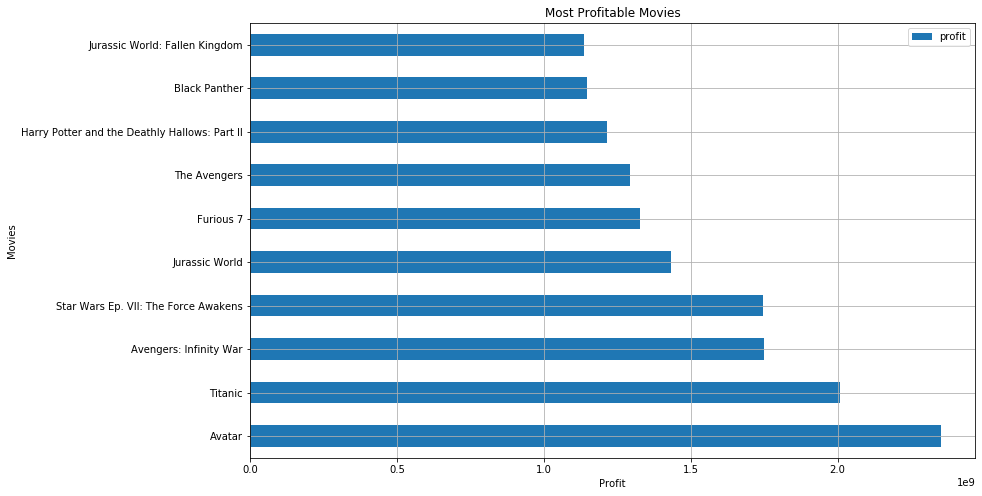

In [18]:
# plotting data as a bar graph
df3.plot(kind='barh', figsize=(13,8))
plt.title('Most Profitable Movies')
plt.xlabel('Profit')
plt.ylabel('Movies')
plt.legend()
plt.grid(True)

plt.show()